## Section 0: Setup & Imports

In [1]:
import sys
sys.path.append("../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_train, load_test
from src.config import TARGET_COL, ID_COL, SEED

# Style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

## Section 1: Data Loading & Quality Check

In [2]:
train = load_train().set_index(ID_COL)
test = load_test().set_index(ID_COL)

print(f"Train shape: {train.shape}")
print(f"Test  shape: {test.shape}")
print(f"\nTrain columns: {list(train.columns)}")
print(f"Test  columns: {list(test.columns)}")

Train shape: (445, 8)
Test  shape: (446, 7)

Train columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Test  columns: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [3]:
train.info()

<class 'pandas.DataFrame'>
Index: 445 entries, 3 to 888
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  445 non-null    int64  
 1   pclass    445 non-null    int64  
 2   sex       445 non-null    str    
 3   age       360 non-null    float64
 4   sibsp     445 non-null    int64  
 5   parch     445 non-null    int64  
 6   fare      445 non-null    float64
 7   embarked  443 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 31.3 KB


In [4]:
train.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked
id,,,,,,,,
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
7,0,3,male,2.0,3,1,21.0750,S
9,1,2,female,14.0,1,0,30.0708,C
11,1,1,female,58.0,0,0,26.5500,S
13,0,3,male,39.0,1,5,31.2750,S
16,0,3,male,2.0,4,1,29.1250,Q
19,1,3,female,NaN,0,0,7.2250,C
23,1,1,male,28.0,0,0,35.5000,S


In [5]:
train.describe()

,survived,pclass,age,sibsp,parch,fare
count,445.000000,445.000000,360.000000,445.000000,445.000000,445.000000
mean,0.402247,2.296629,29.211583,0.546067,0.431461,33.959971
std,0.490903,0.834024,14.154300,1.195247,0.850489,52.079492
min,0.000000,1.000000,0.670000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.000000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.000000
75%,1.000000,3.000000,37.250000,1.000000,1.000000,31.387500
max,1.000000,3.000000,80.000000,8.000000,5.000000,512.329200


In [6]:
train.describe(include="object")

/tmp/ipykernel_186014/4058271388.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.describe(include="object")


,sex,embarked
count,445,443
unique,2,3
top,male,S
freq,289,325


          n_missing  pct_missing dataset
age              85        19.10   train
embarked          2         0.45   train
age              92        20.63    test


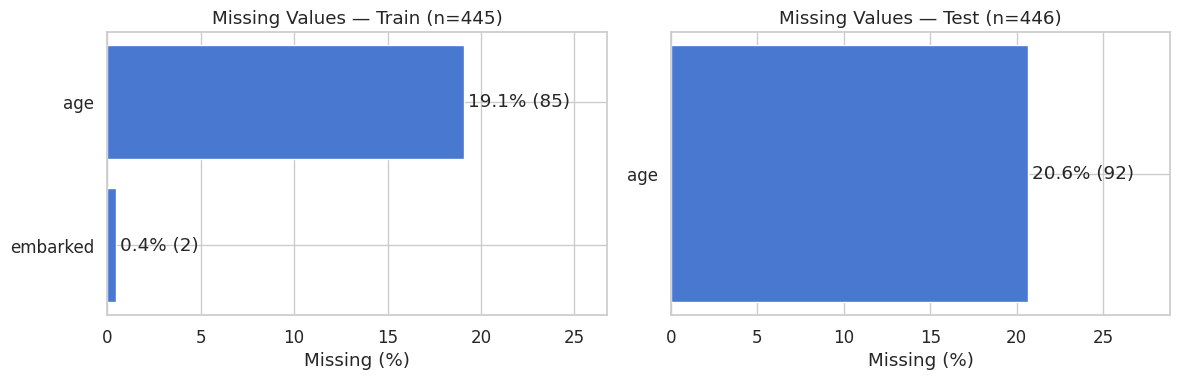

In [7]:
# Missing value summary for train and test
def missing_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    n_miss = df.isnull().sum()
    pct_miss = (n_miss / len(df) * 100).round(2)
    return pd.DataFrame({"n_missing": n_miss, "pct_missing": pct_miss}, index=df.columns).query("n_missing > 0").sort_values("pct_missing", ascending=False).assign(dataset=name)

miss_train = missing_summary(train, "train")
miss_test = missing_summary(test, "test")
miss_all = pd.concat([miss_train, miss_test])
print(miss_all.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, df) in zip(axes, [("Train", train), ("Test", test)]):
    n_miss = df.isnull().sum()
    n_miss = n_miss[n_miss > 0].sort_values(ascending=True)
    pct = (n_miss / len(df) * 100)
    bars = ax.barh(n_miss.index, pct)
    ax.bar_label(bars, labels=[f"{v:.1f}% ({n})" for v, n in zip(pct, n_miss)], padding=3)
    ax.set_xlabel("Missing (%)")
    ax.set_title(f"Missing Values — {name} (n={len(df)})")
    ax.set_xlim(0, pct.max() * 1.4 if len(pct) > 0 else 1)
plt.tight_layout()
plt.show()

In [8]:
# Duplicate rows check
n_dup_train = train.duplicated().sum()
n_dup_test = test.duplicated().sum()
print(f"Duplicate rows — Train: {n_dup_train}, Test: {n_dup_test}")

Duplicate rows — Train: 35, Test: 38


## Section 2: Target Variable Structure

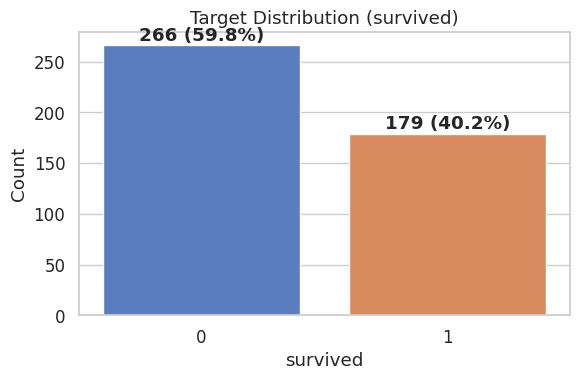

Class ratio (died:survived) = 266:179 ≈ 1.49:1


In [9]:
vc = train[TARGET_COL].value_counts()
pct = train[TARGET_COL].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = sns.countplot(x=TARGET_COL, data=train, ax=ax, hue=TARGET_COL, legend=False)
for i, (count, p) in enumerate(zip(vc.sort_index(), pct.sort_index())):
    ax.text(i, count + 5, f"{count} ({p:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Target Distribution (survived)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Class ratio (died:survived) = {vc[0]}:{vc[1]} ≈ {vc[0]/vc[1]:.2f}:1")

## Section 3: Univariate Analysis

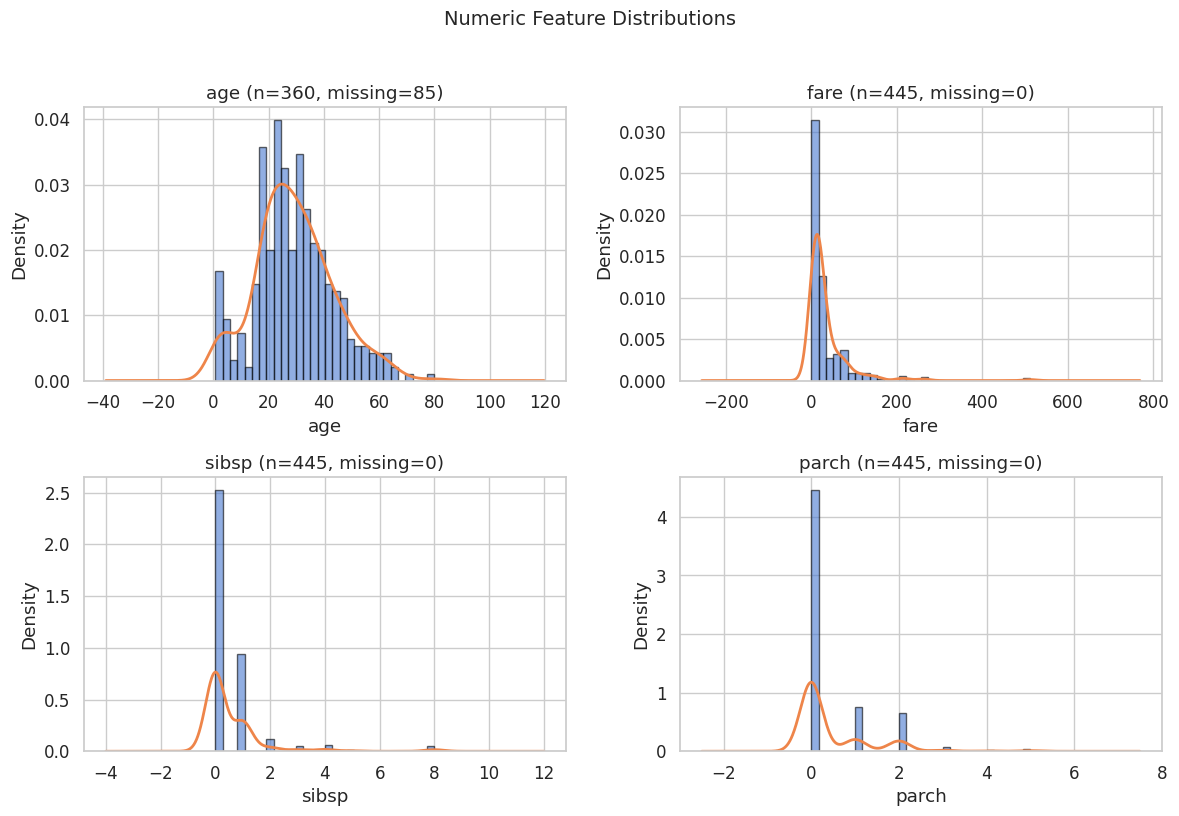

In [10]:
# Numeric features: histograms + KDE
num_cols = ["age", "fare", "sibsp", "parch"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    train[col].dropna().hist(bins=30, ax=ax, density=True, alpha=0.6, edgecolor="black")
    train[col].dropna().plot.kde(ax=ax, linewidth=2)
    ax.set_title(f"{col} (n={train[col].notna().sum()}, missing={train[col].isna().sum()})")
    ax.set_xlabel(col)
plt.suptitle("Numeric Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

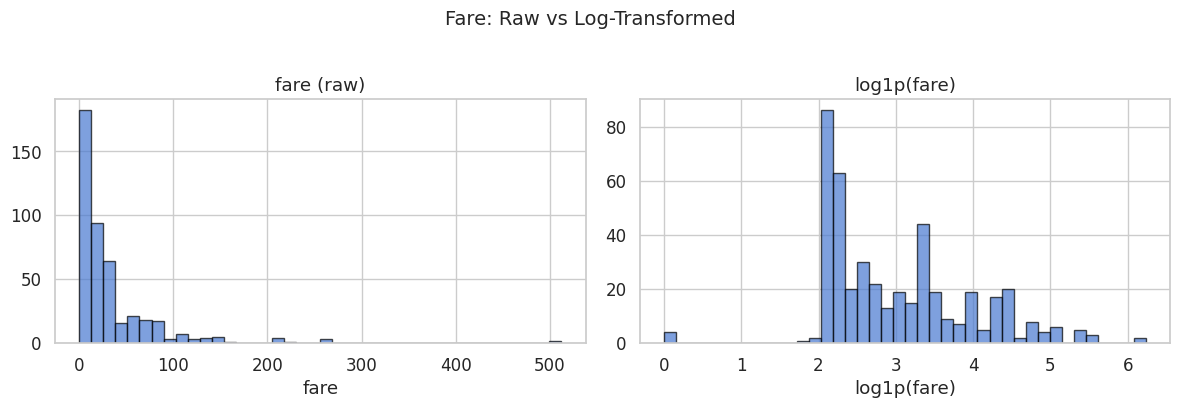

fare skewness: raw=4.86, log1p=0.58


In [11]:
# Fare: log transformation effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train["fare"].hist(bins=40, ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_title("fare (raw)")
axes[0].set_xlabel("fare")

np.log1p(train["fare"]).hist(bins=40, ax=axes[1], edgecolor="black", alpha=0.7)
axes[1].set_title("log1p(fare)")
axes[1].set_xlabel("log1p(fare)")

plt.suptitle("Fare: Raw vs Log-Transformed", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print(f"fare skewness: raw={train['fare'].skew():.2f}, log1p={np.log1p(train['fare']).skew():.2f}")

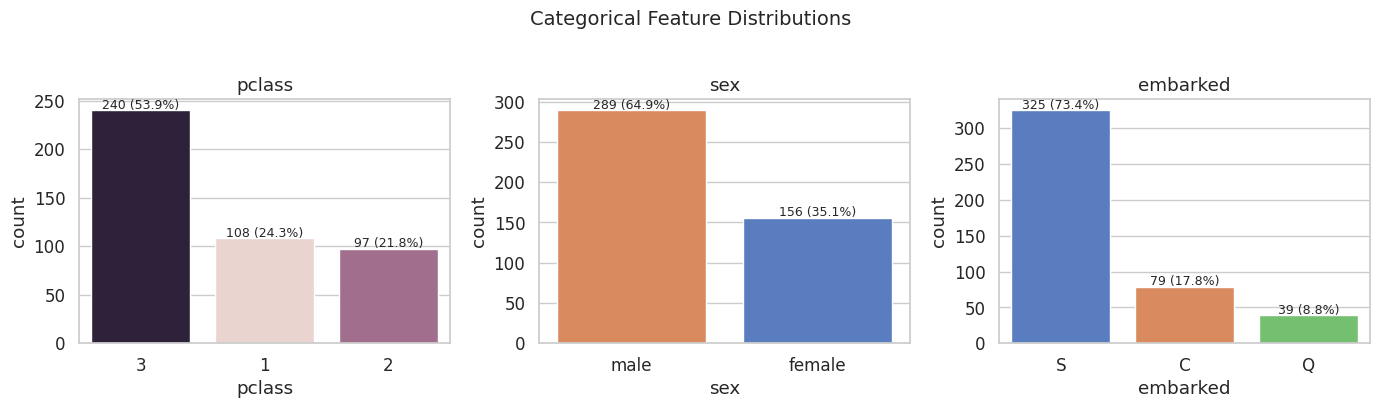

In [12]:
# Categorical features: count plots
cat_cols = ["pclass", "sex", "embarked"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    order = train[col].value_counts().index
    sns.countplot(x=col, data=train, ax=ax, order=order, hue=col, legend=False)
    total = train[col].notna().sum()
    for p in ax.patches:
        h = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2, h + 2, f"{int(h)} ({h/total*100:.1f}%)",
                ha="center", fontsize=9)
    ax.set_title(f"{col}")
plt.suptitle("Categorical Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Section 4: Bivariate Analysis (Feature vs Survival)

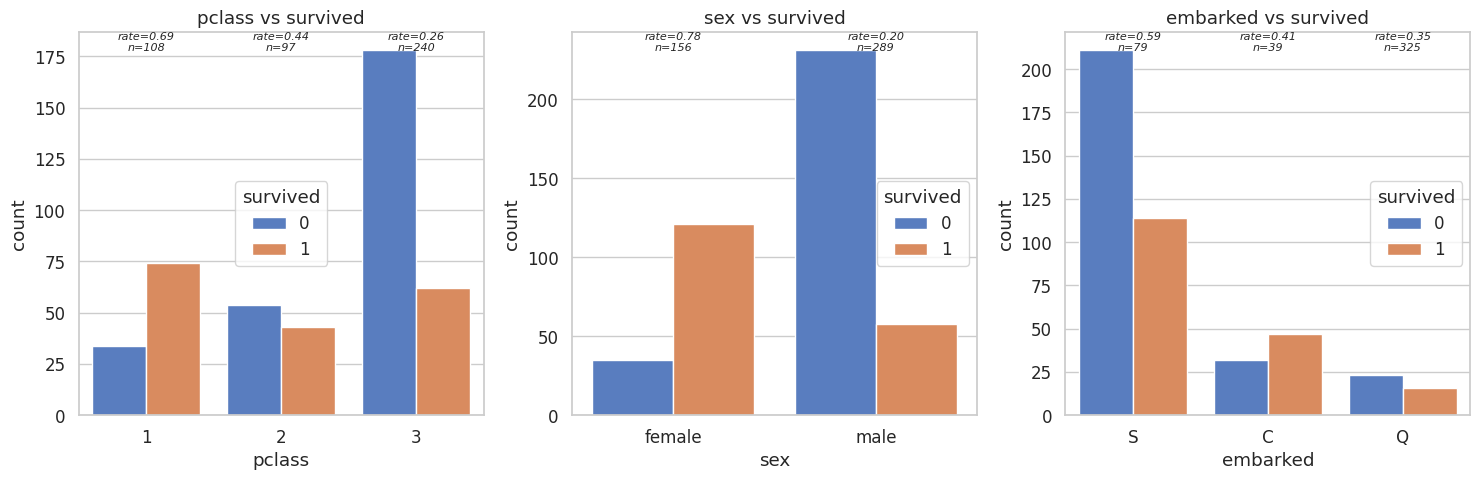

In [13]:
# Categorical features vs survived
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["pclass", "sex", "embarked"]):
    sns.countplot(x=col, hue=TARGET_COL, data=train, ax=ax)
    ax.set_title(f"{col} vs {TARGET_COL}")
    # Add survival rate as text
    rates = train.groupby(col)[TARGET_COL].mean()
    for i, (cat, rate) in enumerate(rates.items()):
        n = (train[col] == cat).sum()
        ax.text(i, ax.get_ylim()[1] * 0.95, f"rate={rate:.2f}\nn={n}",
                ha="center", fontsize=8, style="italic")
plt.tight_layout()
plt.show()

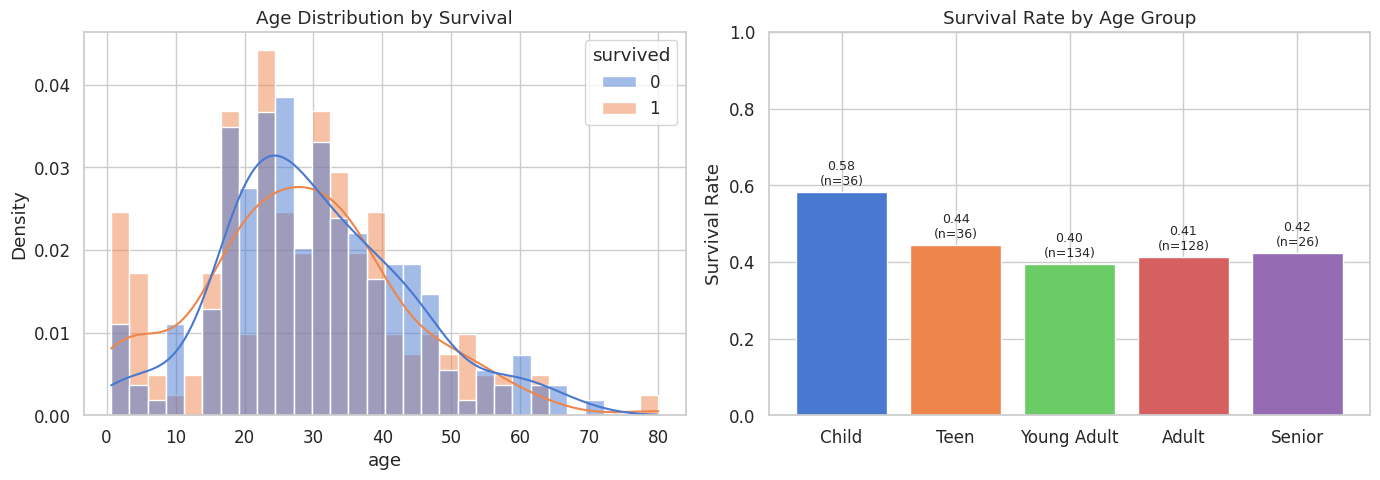

In [14]:
# Age vs survived
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram overlay
sns.histplot(data=train.dropna(subset=["age"]), x="age", hue=TARGET_COL, kde=True,
             bins=30, ax=axes[0], stat="density", common_norm=False)
axes[0].set_title("Age Distribution by Survival")

# Age binning — survival rate
df_tmp = train.dropna(subset=["age"]).copy()
bins = [0, 12, 18, 30, 50, 80]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]
df_tmp["age_bin"] = pd.cut(df_tmp["age"], bins=bins, labels=labels)
age_stats = df_tmp.groupby("age_bin", observed=False)[TARGET_COL].agg(["mean", "count"])
bars = axes[1].bar(age_stats.index, age_stats["mean"], color=sns.color_palette("muted"))
axes[1].bar_label(bars, labels=[f"{m:.2f}\n(n={int(c)})" for m, c in zip(age_stats["mean"], age_stats["count"])],
                  padding=3, fontsize=9)
axes[1].set_title("Survival Rate by Age Group")
axes[1].set_ylabel("Survival Rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

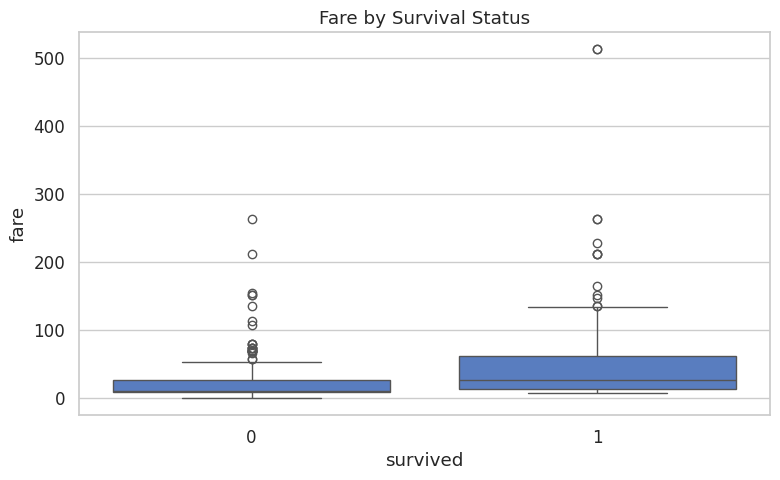

          count   mean    std   min    25%   50%    75%     max
survived                                                       
0         266.0  22.92  30.91  0.00   7.85  10.5  26.00  263.00
1         179.0  50.36  69.93  6.98  12.74  26.0  61.49  512.33


In [15]:
# Fare vs survived — boxplot
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=TARGET_COL, y="fare", data=train, ax=ax)
ax.set_title("Fare by Survival Status")
plt.tight_layout()
plt.show()

# Summary stats
print(train.groupby(TARGET_COL)["fare"].describe().round(2))

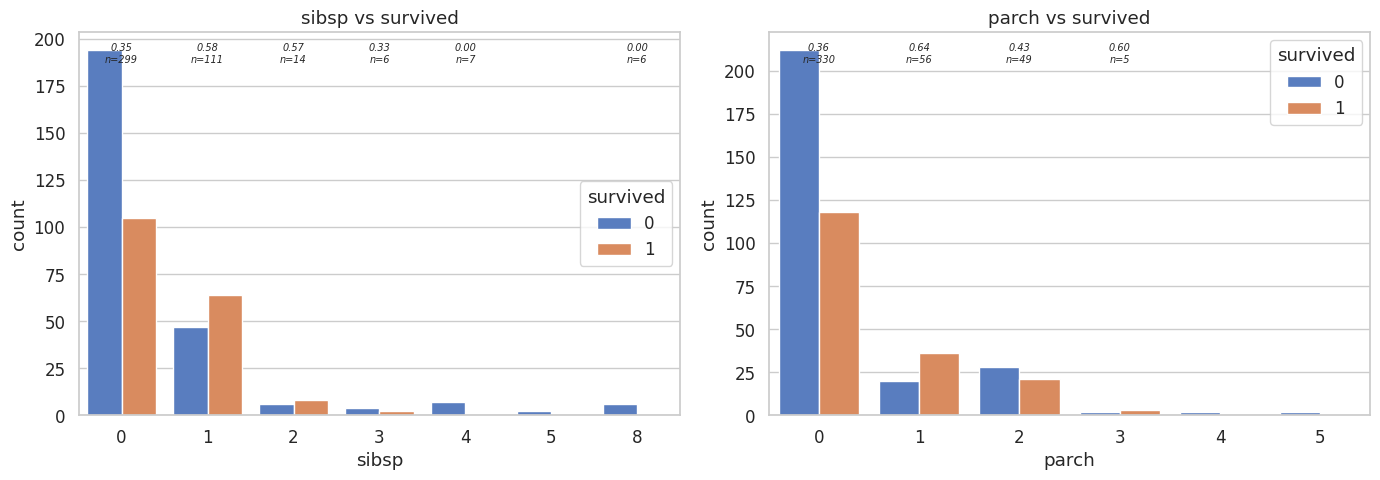

In [16]:
# SibSp / Parch vs survived
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ["sibsp", "parch"]):
    sns.countplot(x=col, hue=TARGET_COL, data=train, ax=ax)
    ax.set_title(f"{col} vs {TARGET_COL}")
    # Annotate survival rate per category
    rates = train.groupby(col)[TARGET_COL].agg(["mean", "count"])
    for i, (idx, row) in enumerate(rates.iterrows()):
        if row["count"] >= 5:  # only annotate groups with n>=5
            ax.text(i, ax.get_ylim()[1] * 0.92, f"{row['mean']:.2f}\nn={int(row['count'])}",
                    ha="center", fontsize=7, style="italic")
plt.tight_layout()
plt.show()

## Section 5: Correlation Analysis

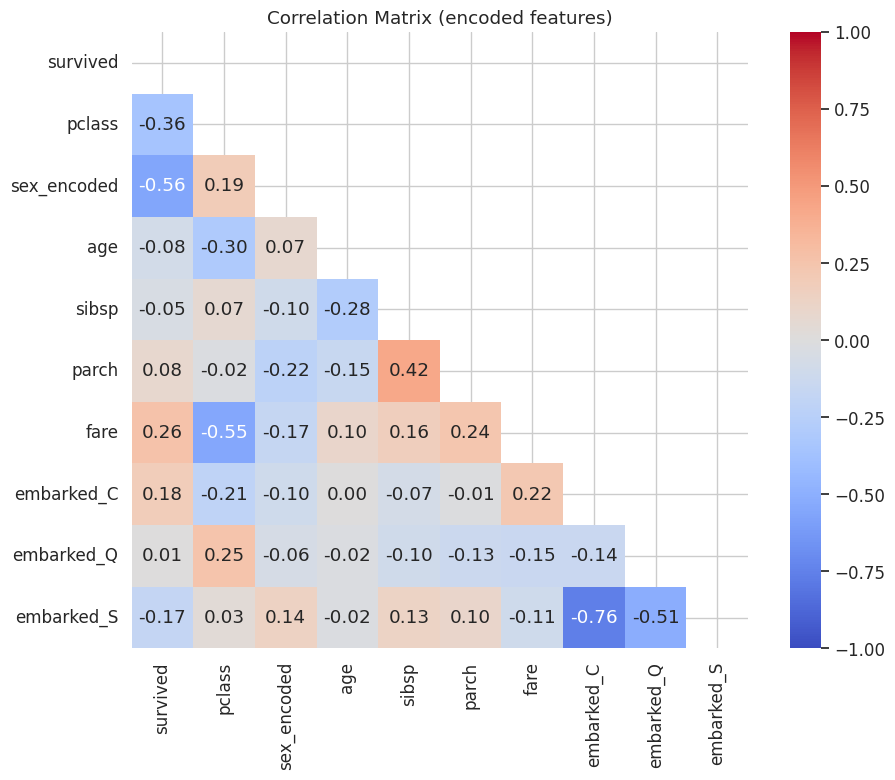

In [17]:
# Encode categorical for correlation
train_enc = train.copy()
train_enc["sex_encoded"] = (train_enc["sex"] == "male").astype(int)
embarked_dummies = pd.get_dummies(train_enc["embarked"], prefix="embarked", dtype=int)
train_enc = pd.concat([train_enc, embarked_dummies], axis=1)

corr_cols = [TARGET_COL, "pclass", "sex_encoded", "age", "sibsp", "parch", "fare"] + list(embarked_dummies.columns)
corr_matrix = train_enc[corr_cols].corr()

# Heatmap with upper triangle mask
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Correlation Matrix (encoded features)")
plt.tight_layout()
plt.show()

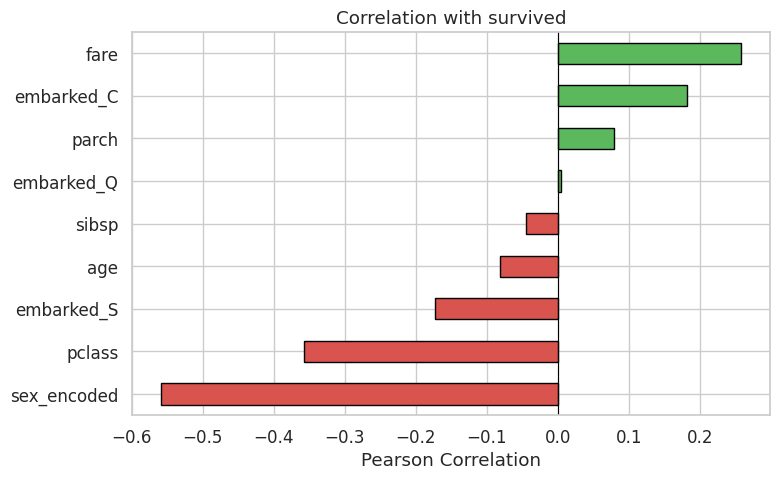

In [18]:
# Correlation with survived — horizontal bar chart
corr_with_target = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values()
colors = ["#d9534f" if v < 0 else "#5cb85c" for v in corr_with_target]

fig, ax = plt.subplots(figsize=(8, 5))
corr_with_target.plot.barh(ax=ax, color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Correlation with {TARGET_COL}")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

## Section 6: Multivariate & Interaction Analysis

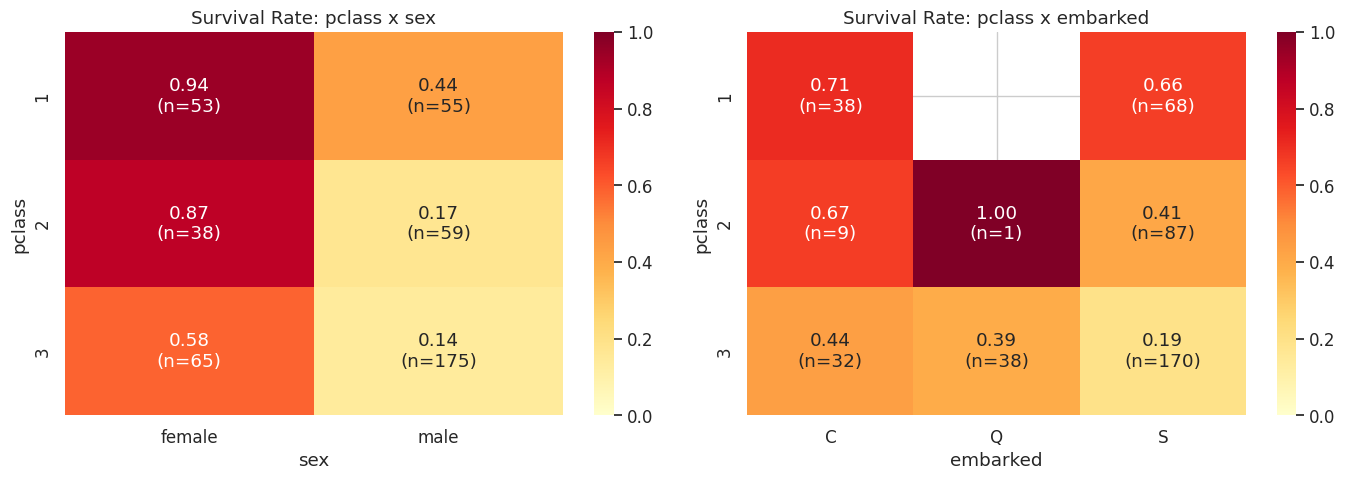

In [19]:
# Conditional survival rate heatmaps: pclass x sex, pclass x embarked
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def make_annot(pivot_mean, pivot_count):
    """Build annotation strings, handling NaN gracefully."""
    annot = pivot_mean.copy().astype(str)
    for r in pivot_mean.index:
        for c in pivot_mean.columns:
            m = pivot_mean.loc[r, c]
            n = pivot_count.loc[r, c] if (r in pivot_count.index and c in pivot_count.columns) else 0
            if pd.isna(m) or pd.isna(n):
                annot.loc[r, c] = ""
            else:
                annot.loc[r, c] = f"{m:.2f}\n(n={int(n)})"
    return annot

# pclass x sex
pivot1 = train.pivot_table(values=TARGET_COL, index="pclass", columns="sex", aggfunc="mean")
count1 = train.pivot_table(values=TARGET_COL, index="pclass", columns="sex", aggfunc="count")
annot1 = make_annot(pivot1, count1)
sns.heatmap(pivot1, annot=annot1, fmt="", cmap="YlOrRd", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Survival Rate: pclass x sex")

# pclass x embarked
pivot2 = train.pivot_table(values=TARGET_COL, index="pclass", columns="embarked", aggfunc="mean")
count2 = train.pivot_table(values=TARGET_COL, index="pclass", columns="embarked", aggfunc="count")
annot2 = make_annot(pivot2, count2)
sns.heatmap(pivot2, annot=annot2, fmt="", cmap="YlOrRd", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Survival Rate: pclass x embarked")

plt.tight_layout()
plt.show()

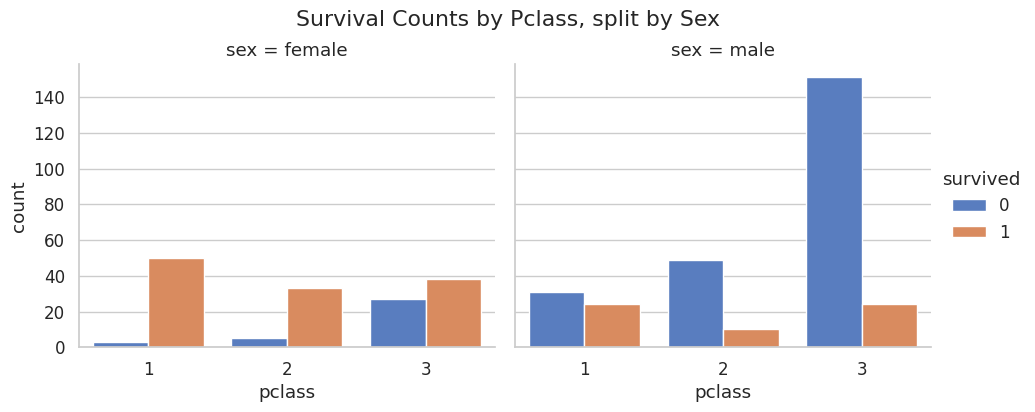

In [20]:
# pclass x sex x survived — catplot
g = sns.catplot(data=train, x="pclass", hue=TARGET_COL, col="sex",
                kind="count", height=4, aspect=1.2)
g.figure.suptitle("Survival Counts by Pclass, split by Sex", y=1.03)
plt.show()

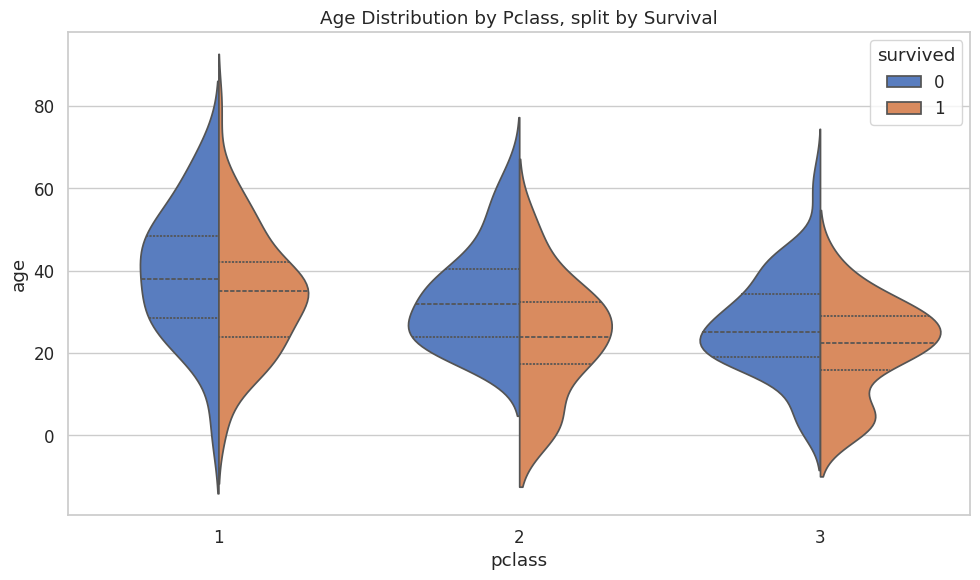

In [21]:
# Age x Pclass — violin plot split by survived
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(x="pclass", y="age", hue=TARGET_COL, data=train.dropna(subset=["age"]),
               split=True, inner="quart", ax=ax)
ax.set_title("Age Distribution by Pclass, split by Survival")
plt.tight_layout()
plt.show()

### Derived Feature Exploration

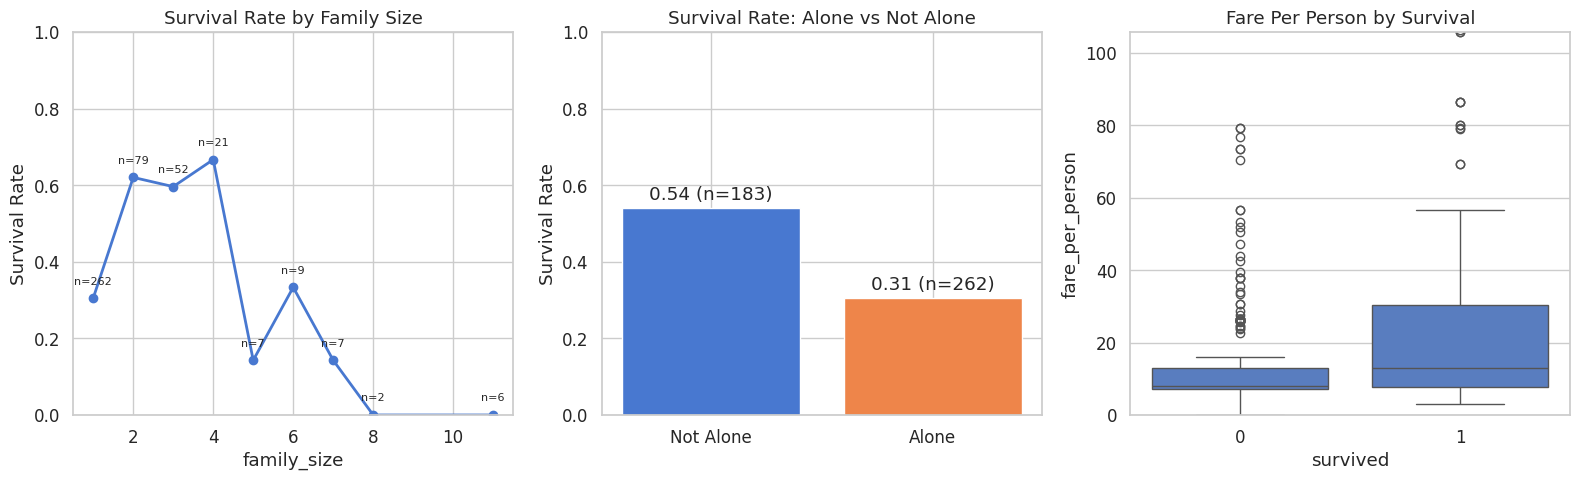

In [22]:
# Derived features (on a copy to avoid polluting original data)
df = train.copy()
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["is_alone"] = (df["family_size"] == 1).astype(int)
df["fare_per_person"] = df["fare"] / df["family_size"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# family_size survival rate curve (U-shape check)
fs_stats = df.groupby("family_size")[TARGET_COL].agg(["mean", "count"])
ax = axes[0]
ax.plot(fs_stats.index, fs_stats["mean"], marker="o", linewidth=2)
for x, row in fs_stats.iterrows():
    ax.annotate(f"n={int(row['count'])}", (x, row["mean"]), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8)
ax.set_title("Survival Rate by Family Size")
ax.set_xlabel("family_size")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)

# is_alone barplot
ax = axes[1]
alone_stats = df.groupby("is_alone")[TARGET_COL].agg(["mean", "count"])
bars = ax.bar(["Not Alone", "Alone"], alone_stats["mean"], color=sns.color_palette("muted")[:2])
ax.bar_label(bars, labels=[f"{m:.2f} (n={int(c)})" for m, c in zip(alone_stats["mean"], alone_stats["count"])],
             padding=3)
ax.set_title("Survival Rate: Alone vs Not Alone")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)

# fare_per_person boxplot
ax = axes[2]
sns.boxplot(x=TARGET_COL, y="fare_per_person", data=df, ax=ax)
ax.set_title("Fare Per Person by Survival")
ax.set_ylim(0, df["fare_per_person"].quantile(0.98))  # clip outliers for visibility

plt.tight_layout()
plt.show()

## Section 7: Missing Value Mechanism Analysis

Investigate whether `age` missingness is MCAR (completely random) or MAR (related to other features).

In [23]:
# Age missing vs non-missing: survival rate comparison
train_age = train.copy()
train_age["age_missing"] = train_age["age"].isna().astype(int)

print("=== Survival rate by age missingness ===")
print(train_age.groupby("age_missing")[TARGET_COL].agg(["mean", "count"]))
print()

# Profile of age-missing passengers
print("=== Profile of passengers with missing age ===")
profile_cols = ["pclass", "fare", TARGET_COL]
for col in profile_cols:
    print(f"\n{col}:")
    print(train_age.groupby("age_missing")[col].mean().to_frame().T)

=== Survival rate by age missingness ===
                 mean  count
age_missing                 
0            0.427778    360
1            0.294118     85

=== Profile of passengers with missing age ===

pclass:
age_missing         0         1
pclass       2.202778  2.694118

fare:
age_missing          0          1
fare         37.505231  18.944753

survived:
age_missing         0         1
survived     0.427778  0.294118


In [24]:
# Detailed breakdown: age missing by pclass and sex
print("=== Age missing rate by pclass ===")
print(train_age.groupby("pclass")["age_missing"].mean().map("{:.2%}".format))
print()
print("=== Age missing rate by sex ===")
print(train_age.groupby("sex")["age_missing"].mean().map("{:.2%}".format))
print()
print("=== Age missing rate by pclass x sex ===")
print(train_age.pivot_table(values="age_missing", index="pclass", columns="sex", aggfunc="mean").map("{:.2%}".format))
print()
print("→ If rates differ across groups, age is MAR (missing at random conditional on other features).")
print("  This supports pclass-based (or pclass×sex) median imputation over global median.")

=== Age missing rate by pclass ===
pclass
1    10.19%
2     4.12%
3    29.17%
Name: age_missing, dtype: str

=== Age missing rate by sex ===
sex
female    16.03%
male      20.76%
Name: age_missing, dtype: str

=== Age missing rate by pclass x sex ===
sex     female    male
pclass                
1        5.66%  14.55%
2        0.00%   6.78%
3       33.85%  27.43%

→ If rates differ across groups, age is MAR (missing at random conditional on other features).
  This supports pclass-based (or pclass×sex) median imputation over global median.


## Section 8: Train vs Test Distribution Comparison

Check for domain shift between train and test sets.

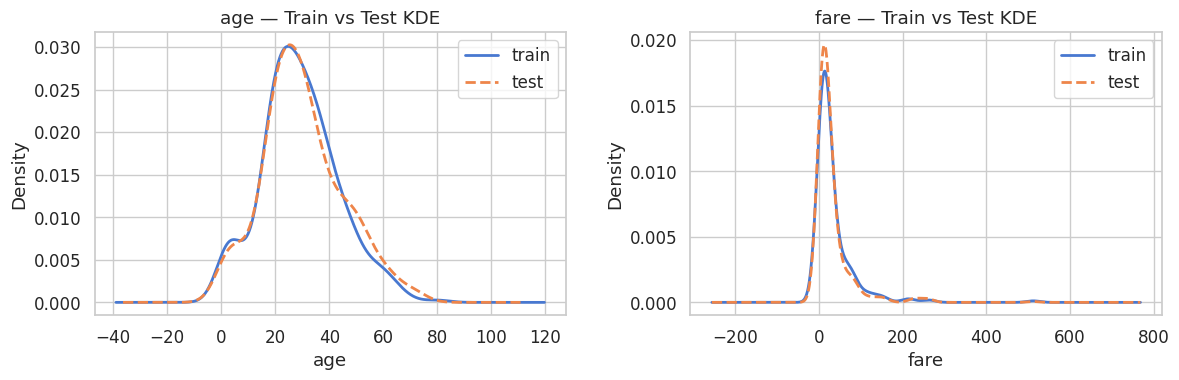

In [25]:
# Numeric features: KDE overlay (train vs test)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["age", "fare"]):
    train[col].dropna().plot.kde(ax=ax, label="train", linewidth=2)
    test[col].dropna().plot.kde(ax=ax, label="test", linewidth=2, linestyle="--")
    ax.set_title(f"{col} — Train vs Test KDE")
    ax.legend()
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

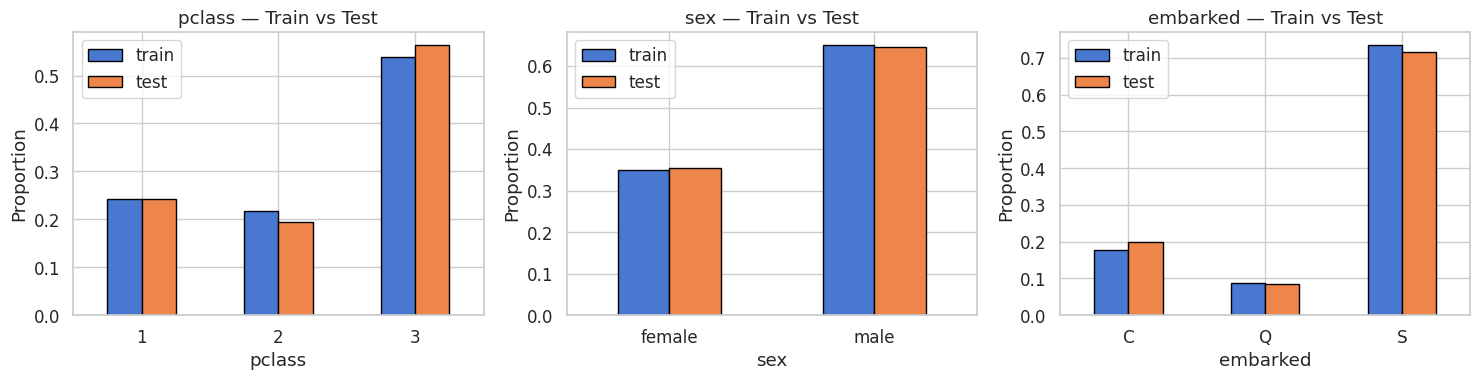

In [26]:
# Categorical features: normalized bar comparison (train vs test)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["pclass", "sex", "embarked"]):
    train_pct = train[col].value_counts(normalize=True).sort_index()
    test_pct = test[col].value_counts(normalize=True).sort_index()
    comp = pd.DataFrame({"train": train_pct, "test": test_pct})
    comp.plot.bar(ax=ax, rot=0, edgecolor="black")
    ax.set_title(f"{col} — Train vs Test")
    ax.set_ylabel("Proportion")
    ax.legend()
plt.tight_layout()
plt.show()

## Section 9: Findings Summary & Feature Engineering Strategy

### Key Findings

**Strong predictors:**
- `sex`: Female passengers have significantly higher survival rate
- `pclass`: 1st class passengers survived more; strong interaction with sex
- `fare` / `log_fare`: Higher fare → higher survival (correlated with pclass)

**Moderate predictors:**
- `age`: Children (0-12) show higher survival; seniors lower
- `family_size`: U-shaped relationship — solo travelers and very large families have lower survival
- `is_alone`: Solo travelers have lower survival rate

**Interactions to capture:**
- `pclass × sex`: The most powerful interaction — 3rd class males have very low survival
- `fare_per_person`: Normalizes shared tickets; may separate within-class effects

**Weak / uncertain:**
- `embarked`: Some signal but confounded with pclass; hold for now

### Feature Engineering Candidates

| Feature | Formula | Rationale |
|---------|---------|-----------|
| `family_size` | `sibsp + parch + 1` | Captures group dynamics |
| `is_alone` | `family_size == 1` | Binary simplification |
| `age_bin` | Binned age groups | Handles nonlinear age effect |
| `log_fare` | `np.log1p(fare)` | Reduces skewness |
| `fare_per_person` | `fare / family_size` | Normalizes shared tickets |
| `pclass_sex` | `pclass × sex` interaction | Strongest interaction |

### Missing Value Strategy
- `age`: **pclass-based (or pclass×sex) median imputation** — supported by MAR evidence from Section 7
- `embarked`: Mode imputation (very few missing)
- `fare`: Median imputation by pclass (test set)

### Cautions
- `fare` and `pclass` are highly correlated → watch for multicollinearity in linear models
- `fare == 0` anomalies exist → investigate or clip
- Small sample sizes in some subgroups (e.g., embarked=Q × pclass=1) → avoid over-interpreting

### Next Actions
1. Implement features in `src/features.py`
2. Set up CV pipeline with `StratifiedKFold(n_splits=5)`
3. Baseline model comparison (LogReg, RF, XGB, LGBM)

> **Remember:** All EDA findings are hypotheses. Validate via cross-validation!

In [27]:
# Cleanup: remove temporary variables from this notebook's scope
del df, df_tmp, train_enc, train_age
del corr_matrix, corr_with_target, miss_train, miss_test, miss_all
print("Temporary analysis variables cleaned up.")

Temporary analysis variables cleaned up.


# Comprehensive EDA — Titanic Survival Prediction

Go beyond basic `value_counts` / `groupby` analysis.  
Goals:
1. Understand data quality (missing values, duplicates, distributions)
2. Identify promising features and interactions
3. Inform feature engineering strategy for modeling phase

> **Note:** All findings here are *hypotheses* — they must be validated via CV in the modeling stage.